In [2]:
from sqlalchemy import create_engine
import pandas as pd
import logging
from pathlib import Path

# 配置日志
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def get_chat_data(db_path):
    """
    获取chat表的所有数据并转换为DataFrame
    
    Args:
        db_path (str): 数据库文件路径
    
    Returns:
        pd.DataFrame: 包含chat表数据的DataFrame
    """
    try:
        # 创建数据库连接
        engine = create_engine(f'sqlite:///{db_path}')
        
        # 读取chat表数据
        query = """ 
        select a.*,b.name
        from (
        SELECT * from feedback) a 
        left join (
        select id,name from user 
        ) b
        on a.user_id=b.id;
        """
        df = pd.read_sql_query(query, engine)
        
        logger.info(f"成功读取chat表数据，共 {len(df)} 条记录")
        return df
        
    except Exception as e:
        logger.error(f"读取chat表数据时出错: {str(e)}")
        raise

if __name__ == "__main__":
    # 数据库文件路径
    db_path = "../backend/data/webui.db"
    
    # 获取数据
    chat_df = get_chat_data(db_path)
    
    # 显示数据基本信息
    print("\n数据基本信息:")
    print(chat_df.info())
    
    # 显示前几行数据
    print("\n数据预览:")
    print(chat_df.head())
    
    # 显示数据统计信息
    print("\n数据统计信息:")
    print(chat_df.describe()) 

2025-07-15 22:27:06,127 - INFO - 成功读取chat表数据，共 270 条记录



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          270 non-null    object
 1   user_id     270 non-null    object
 2   version     270 non-null    int64 
 3   type        270 non-null    object
 4   data        270 non-null    object
 5   meta        270 non-null    object
 6   snapshot    270 non-null    object
 7   created_at  270 non-null    int64 
 8   updated_at  270 non-null    int64 
 9   name        270 non-null    object
dtypes: int64(3), object(7)
memory usage: 21.2+ KB
None

数据预览:
                                     id                               user_id  \
0  fa428607-ec04-4589-ac17-409a025042b3  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
1  190d61e6-1b7c-4cf5-a006-b5888cd0674f  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
2  be9c4313-a040-4f61-9aa1-028399117403  8d7e1db7-c386-46f1-96a2-d5f71ffe11ca   
3  6d648b62-1ffa-40

In [7]:
import json 
import pprint 
with open("tmp_feedback.json","w") as f:
    f.write(json.dumps(json.loads(chat_df.snapshot.tolist()[0]),indent=4,ensure_ascii=False))


with open("tmp_feedback_meta.json","w") as f:
    f.write(json.dumps(json.loads(chat_df.meta.tolist()[0]),indent=4,ensure_ascii=False))

In [17]:
import traceback
feedback_data=[]
import json
for i,r in chat_df.iterrows():
    feedback_id = r['id']
    snapshot = json.loads(r['snapshot'])
    data=json.loads(r['data'])
    rating = data.get("rating",-99)
    rating_score = data.get("details",{}).get("rating",-99)
    rating_comment = data.get("comment","")
    
    if rating == -1:
        rating = "bad"
    elif rating == 1:
        rating = "good"
    else:
        rating = "unknown"

    name= r['name']
    user_id=r['user_id']
    meta=json.loads(r['meta'])
    message_id = meta.get("message_id")
    
    history = snapshot['chat']['chat']['history']
    try:
        history_messages = history['messages']
        query_info = history_messages[message_id]
        parentId = query_info['parentId']
        query = history_messages[parentId]
    except:
        print(traceback.format_exc())
        print(message_id)
        print(history)
        continue

    if name in ['dali','cz',' cz']:
        continue
    # history = snapshot.get("history",{})
    feedback_data.append({
        "feedback_id":feedback_id,
        "user_id":user_id,
        "user_name":name,
        "goog_or_bad":rating,
        "rating_score":rating_score,
        "rating_comment":rating_comment,
        
        "query":query,
        "answer":query_info['content'],
        "model":query_info['model'],

        "role":query_info.get("role"),
        "message_id":message_id,
        "parentId":query_info.get("parentId"),
        "last_child_id":query_info.get("childrenIds",[])[-1] if history.get("childrenIds",[]) else 0,
        "childrenIds":query_info.get("childrenIds"),
        "created_at":query_info.get("timestamp"),

        "meta":meta,
        "data":data,
        "snapshot":snapshot
    })

print("feedback_data",len(feedback_data))
feedback_data[0]

Traceback (most recent call last):
  File "/tmp/ipykernel_322989/4146758168.py", line 27, in <module>
    query_info = history_messages[message_id]
KeyError: '075130c9-31ac-4b97-8329-56c9b8a175a5'

075130c9-31ac-4b97-8329-56c9b8a175a5
{'messages': {'86682189-e6fb-426c-8734-f0b2227a9416': {'id': '86682189-e6fb-426c-8734-f0b2227a9416', 'parentId': None, 'childrenIds': ['6fd1ddb1-b4f3-46a9-81ac-34a90a97890d'], 'role': 'user', 'content': '在干预的过程中，会出现：有时候说多了，有时候有适当的时机但未说。怎么能很准确的把握，让说的每句话都恰到时机，不漏也不多？', 'timestamp': 1750058241, 'models': ['kfs-ds-r1']}, '6fd1ddb1-b4f3-46a9-81ac-34a90a97890d': {'parentId': '86682189-e6fb-426c-8734-f0b2227a9416', 'id': '6fd1ddb1-b4f3-46a9-81ac-34a90a97890d', 'childrenIds': [], 'role': 'assistant', 'content': '>\n\n<details type="reasoning" done="true" duration="9">\n<summary>Thought for 9 seconds</summary>\n> 好的，我现在需要回答用户的问题：“在干预的过程中，会出现：有时候说多了，有时候有适当的时机但未说。怎么能很准确的把握，让说的每句话都恰到时机，不漏也不多？” 根据提供的系统设定和内部搜索引擎返回的内容，我需要结合康复师X的教学理念和内部资料来给出答案。\n> \n> 首先，用户的问题是关于在干预过程中如何精

{'feedback_id': 'b389bd73-78ae-4aa7-9fa6-4ee6aef03df5',
 'user_id': 'bf27aabe-3100-4283-a90e-4edc55baf261',
 'user_name': 'xuchengba',
 'goog_or_bad': 'good',
 'rating_score': -99,
 'rating_comment': None,
 'query': {'id': '0774478e-1bb5-436b-a690-9152cc7a5cbf',
  'parentId': None,
  'childrenIds': ['2277ebfa-6b71-4a57-ad13-440fdf4c9e11'],
  'role': 'user',
  'content': '如何输入多少',
  'timestamp': 1749392755,
  'models': ['kfs-ds-r1']},
 'answer': '>\n\n<details type="reasoning" done="true" duration="9">\n<summary>Thought for 9 seconds</summary>\n> 好的，我现在需要回答用户的问题：“如何输入多少”。首先，我要根据提供的康复师X教学内容概述和内部搜索引擎返回的内容来构建答案。\n> \n> 首先，查看康复师X的教学内容，特别是关于形容词输入的部分。在L4阶段，形容词如“多少”属于需要教授的内容。根据教学内容，输入形容词需要通过对比和多样本来帮助孩子提取特征，并且要结合有意义的生活场景，让孩子理解其功能和应用。\n> \n> 接下来，查看内部搜索引擎返回的内容。例如，文档[1]提到通过选择疑问句，如“你要喝多的还是少的？”，并加大两者的差异，让孩子在强烈对比中理解多少的概念。同时，文档[11]和[27]也讨论了使用实际生活中的情境，如倒饮料时明显区分多和少，或者通过食物量的不同来输入概念。\n> \n> 需要注意以下几点：\n> 1. **使用选择疑问句**：初期用差距大的选项，如多的一杯和少的几滴，帮助孩子明确选择。\n> 2. **实际体验**：让孩子在需要时体验多少带来的结果差异，例如多倒奶粉让饮料更浓，少倒则淡，从而理解多少

In [18]:
import pandas as pd
chat_data_pd=pd.DataFrame(feedback_data)
chat_data_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   feedback_id     257 non-null    object 
 1   user_id         257 non-null    object 
 2   user_name       257 non-null    object 
 3   goog_or_bad     257 non-null    object 
 4   rating_score    256 non-null    float64
 5   rating_comment  103 non-null    object 
 6   query           257 non-null    object 
 7   answer          257 non-null    object 
 8   model           257 non-null    object 
 9   role            257 non-null    object 
 10  message_id      257 non-null    object 
 11  parentId        257 non-null    object 
 12  last_child_id   257 non-null    int64  
 13  childrenIds     257 non-null    object 
 14  created_at      257 non-null    int64  
 15  meta            257 non-null    object 
 16  data            257 non-null    object 
 17  snapshot        257 non-null    obj

In [15]:
chat_data_pd.goog_or_bad.value_counts()

goog_or_bad
good    153
bad     104
Name: count, dtype: int64

In [115]:
chat_data_pd.to_excel("data/feedback_data_20250615_3.xlsx",index=False)

In [113]:
chat_data_pd.groupby("name")['feedback_id'].count()

name
ganglii       3
xuchengba     2
呼呼huhu～      16
地瓜妈          51
宋园梦           3
康复师X壹壹妈       6
杨老师           4
Name: feedback_id, dtype: int64

In [112]:
chat_data_score.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 92
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feedback_id           33 non-null     object 
 1   user_id               33 non-null     object 
 2   name                  33 non-null     object 
 3   goog_or_bad           33 non-null     object 
 4   rating_score          33 non-null     float64
 5   rating_comment        33 non-null     object 
 6   query                 33 non-null     object 
 7   answer                33 non-null     object 
 8   meta                  33 non-null     object 
 9   data                  33 non-null     object 
 10  feedback_all_message  33 non-null     object 
 11  snapshot              33 non-null     object 
dtypes: float64(1), object(11)
memory usage: 3.4+ KB


In [99]:
chat_data_score=chat_data_pd[chat_data_pd.rating_score>0]
chat_data_score.info()
chat_data_score.rating_score.mean()


<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 0 to 92
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   feedback_id           33 non-null     object 
 1   user_id               33 non-null     object 
 2   name                  33 non-null     object 
 3   goog_or_bad           33 non-null     object 
 4   rating_score          33 non-null     float64
 5   rating_comment        33 non-null     object 
 6   query                 33 non-null     object 
 7   answer                33 non-null     object 
 8   meta                  33 non-null     object 
 9   data                  33 non-null     object 
 10  feedback_all_message  33 non-null     object 
 11  snapshot              33 non-null     object 
dtypes: float64(1), object(11)
memory usage: 3.4+ KB


5.2727272727272725

array([[<Axes: title={'center': 'rating_score'}>]], dtype=object)

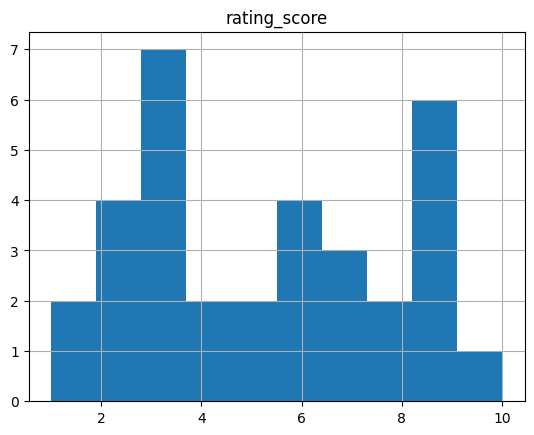

In [95]:
chat_data_score.hist()

feedback_id             10.555556
name                    10.555556
goog_or_bad             10.555556
rating_score            10.222222
rating_comment           4.000000
query                   10.555556
answer                  10.555556
meta                    10.555556
data                    10.555556
feedback_all_message    10.555556
snapshot                10.555556
dtype: float64